## Memory repertoire diversity across ages and time

In [9]:
import numpy as np
import pyrepseq as prs
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.pyplot import Line2D

import repertoire_simulator.lib as lib

plt.style.use("../../project_style.mplstyle")
%config InlineBackend.figure_format = 'retina'

DATA_PATH = "../../data/"

## Richness and diversity in TABLO

In [10]:
tablo = pd.read_csv(DATA_PATH+'tablo/processed/full_table.csv.gz',sep=',')
tablo_memory = tablo[(tablo['annotation_L2'] == 'Memory')]
tablo_memory_blood = tablo[(tablo['annotation_L2'] == 'Memory') & (tablo['origin'] == 'PBMC')]
tablo_memory_tonsil = tablo[(tablo['annotation_L2'] == 'Memory') & (tablo['origin'] == 'Tonsil')]
meta = pd.read_csv(DATA_PATH+'tablo/nonprocessed/10MT_HLA_030123.csv.gz',index_col=0)

In [11]:
dfs = [tablo_memory_blood, tablo_memory_tonsil, tablo_memory]
locs = ["blood", "tonsil", "global"]
metrics = []
for i, df in enumerate(dfs):
    for donor, dfg in df.groupby('donor'):
        
        clone_sizes = np.array(dfg['full_nt'].value_counts())
        
        pc = prs.pc_n(clone_sizes)
        binned_counts = np.bincount(clone_sizes)
        chao1 = prs.chao1(binned_counts[1:])
        
        metrics.append({"donor": donor, "loc":locs[i], "age":meta.loc[donor]['Age'], 'chao1': chao1, 'Seff': 1/pc})
        
df_metrics = pd.DataFrame(metrics)

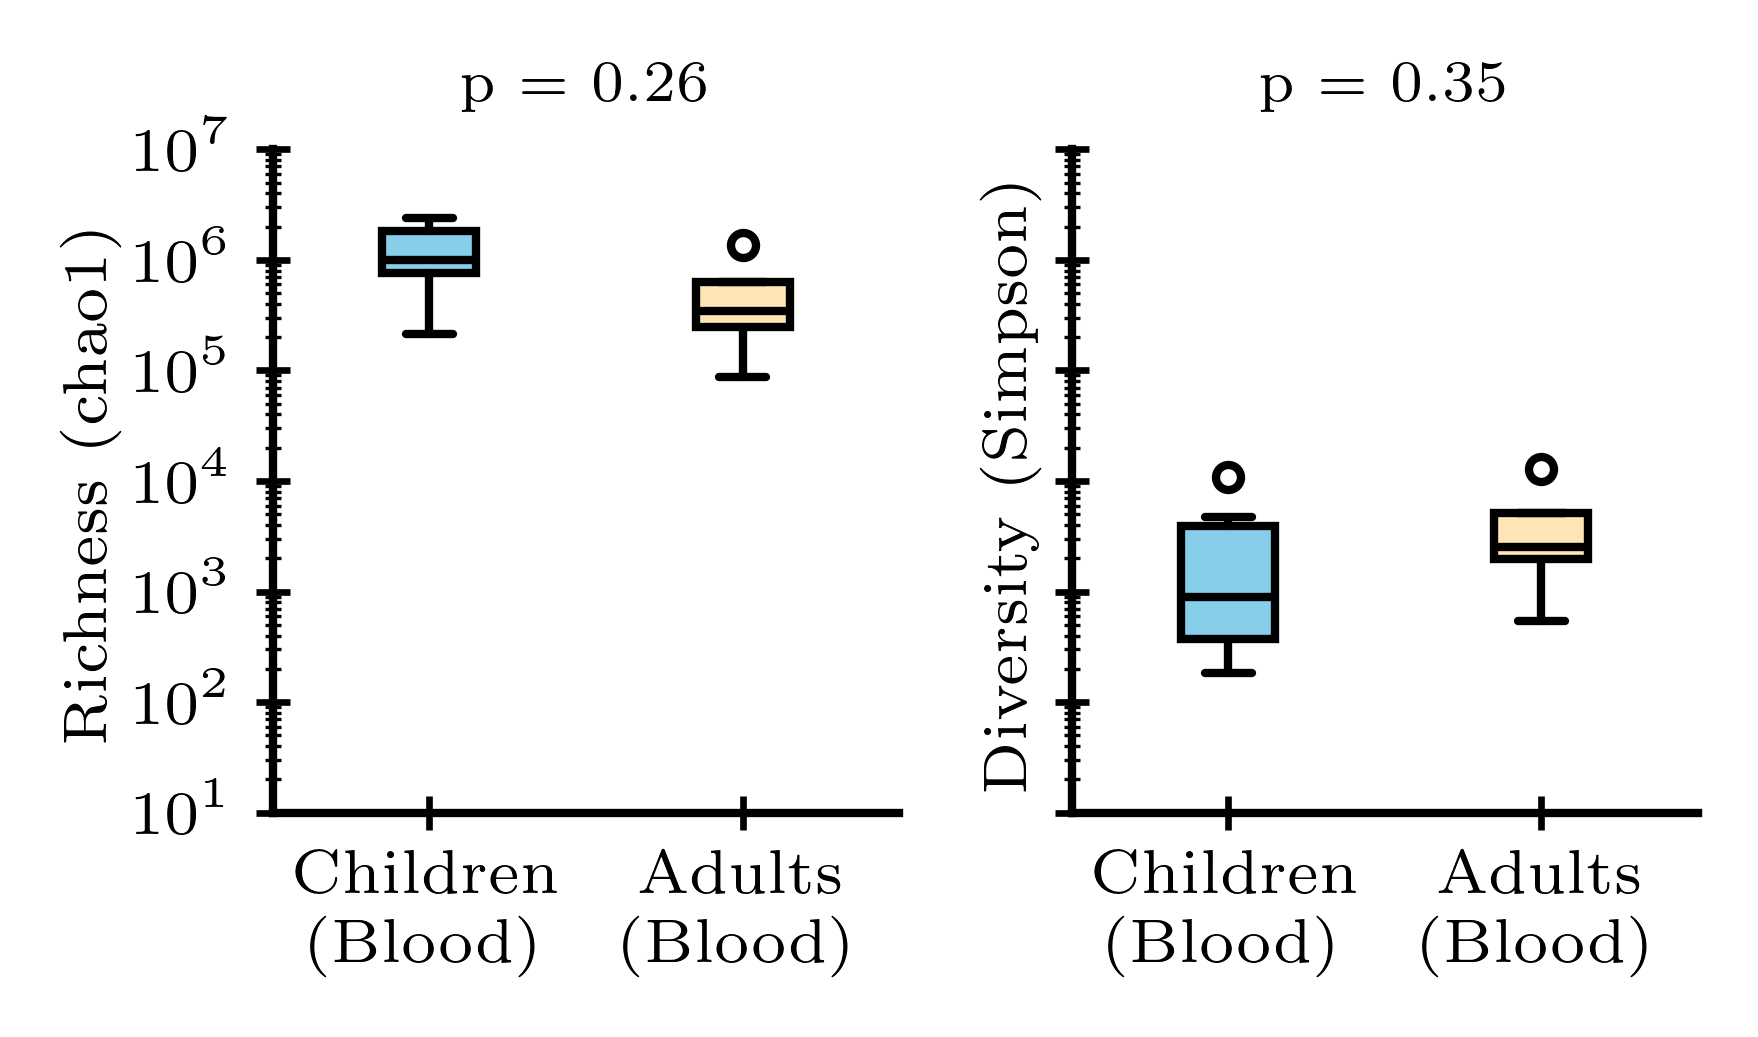

In [12]:
loc = 'blood'
fig, ax = lib.plot_richness_and_diversity_differences(df_metrics[(df_metrics['loc'] == loc) & (df_metrics['age'] <= 10)],
                                                      df_metrics[(df_metrics['loc'] == loc) & (df_metrics['age'] > 10)],
                                                      x_labels=['Children \n (Blood)', 'Adults \n (Blood)'])

plt.savefig('../../figures/how_to_maintain_diversity/tablo_diversity.pdf', bbox_inches='tight', dpi=200, transparent=True);

### Tonsil 

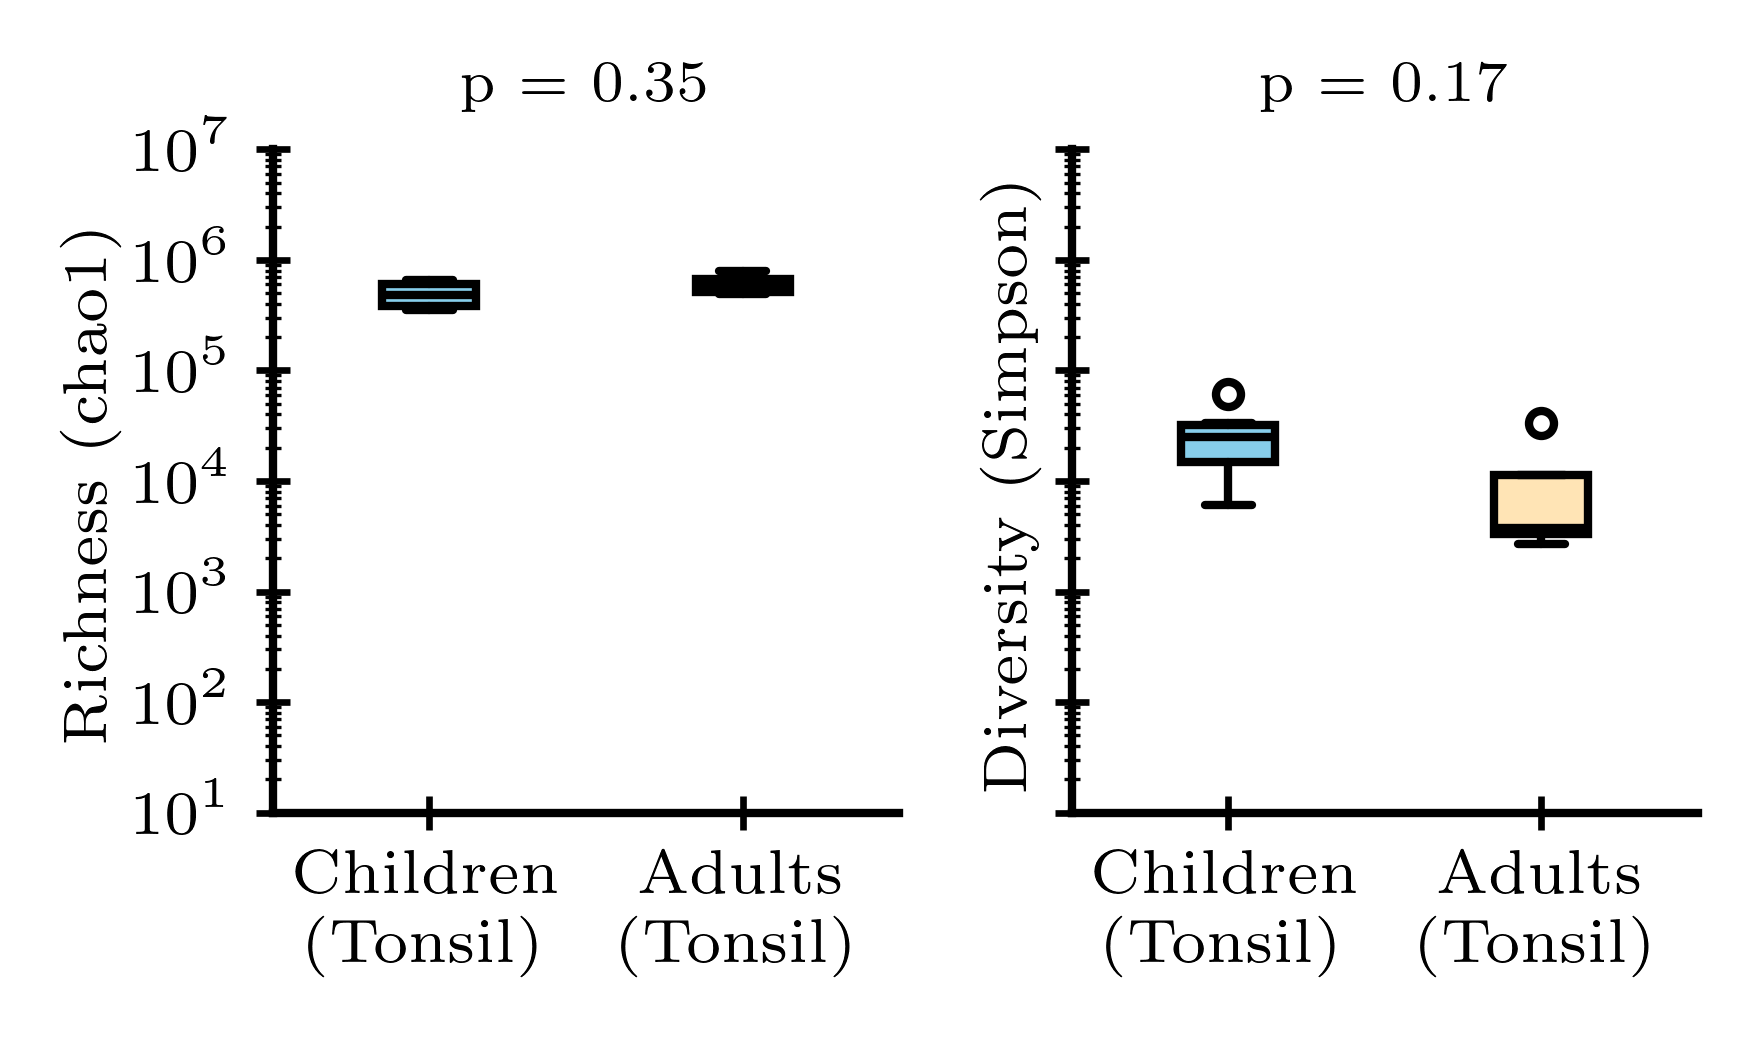

In [13]:
loc = 'tonsil'
fig, ax = lib.plot_richness_and_diversity_differences(df_metrics[(df_metrics['loc'] == loc) & (df_metrics['age'] <= 10)],
                                                      df_metrics[(df_metrics['loc'] == loc) & (df_metrics['age'] > 10)],
                                                      x_labels=['Children \n (Tonsil)', 'Adults \n (Tonsil)'])
plt.savefig('../../figures/how_to_maintain_diversity/tablo_diversity_tonsil.pdf', bbox_inches='tight', dpi=200, transparent=True);

### Global (blood and tonsil)

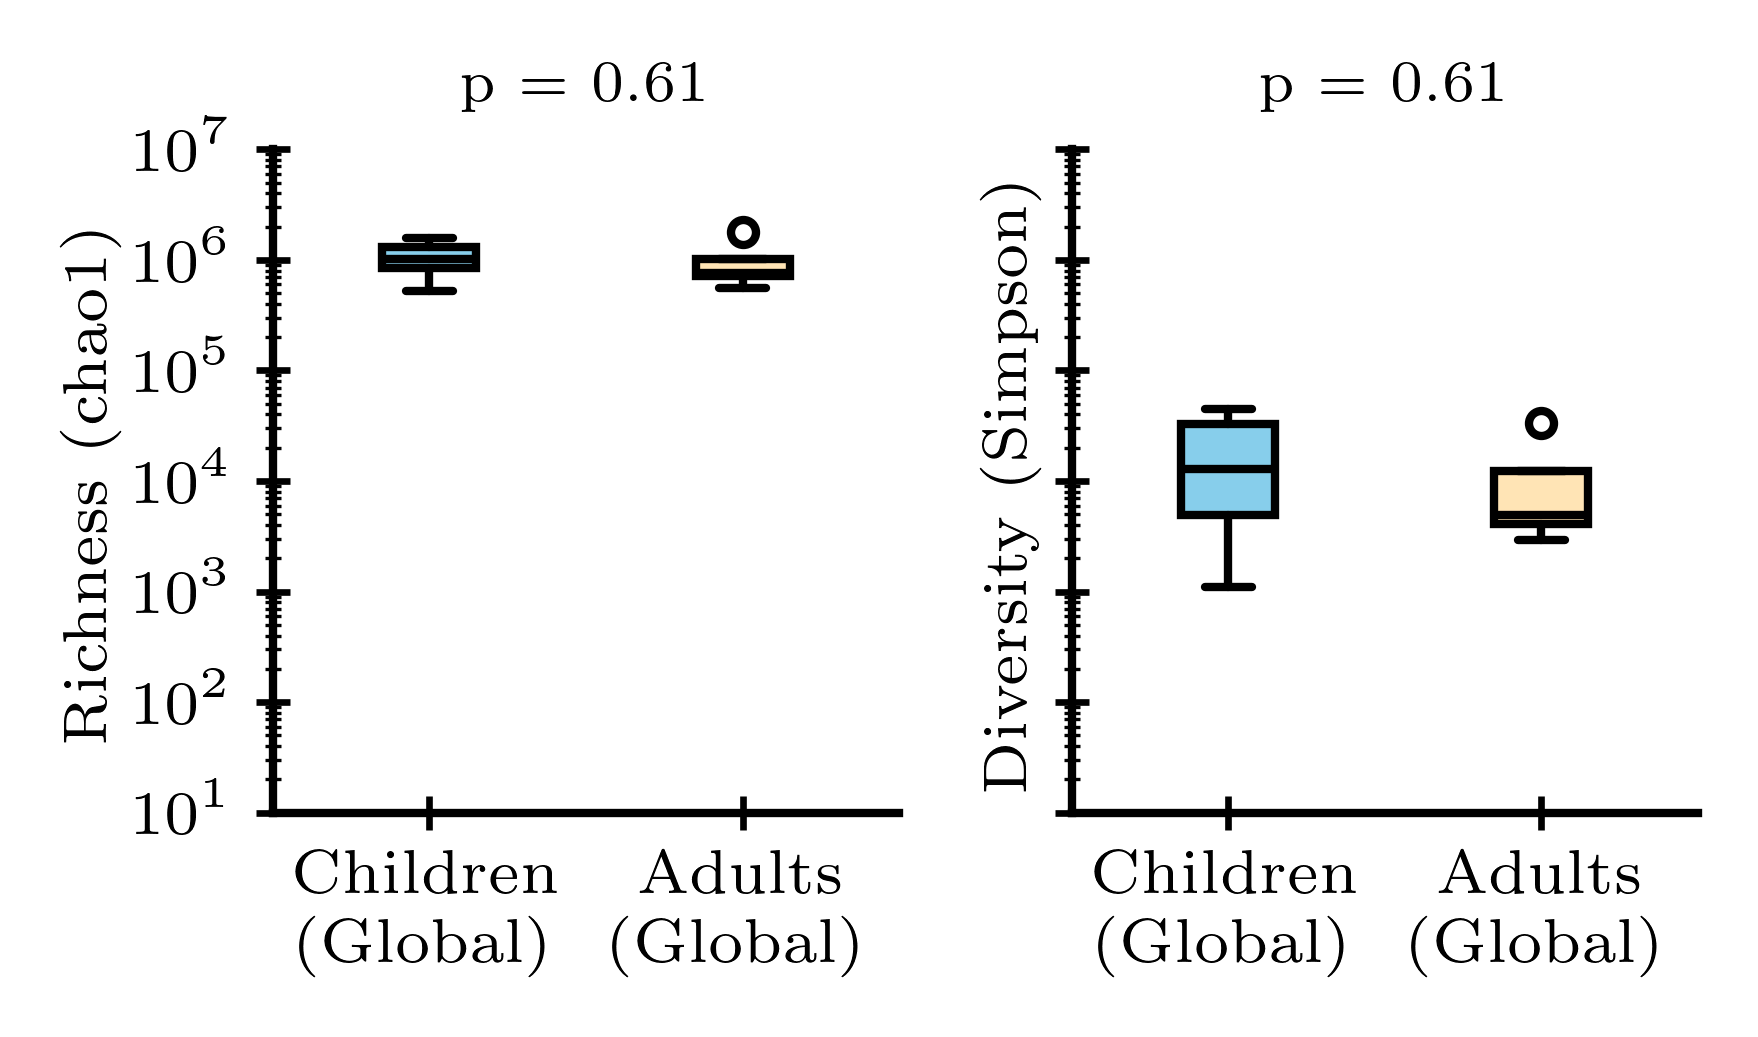

In [14]:
loc = 'global'
fig, ax = lib.plot_richness_and_diversity_differences(df_metrics[(df_metrics['loc'] == loc) & (df_metrics['age'] <= 10)],
                                                      df_metrics[(df_metrics['loc'] == loc) & (df_metrics['age'] > 10)],
                                                      x_labels=['Children \n (Global)', 'Adults \n (Global)'])

## Global and local diversity

### Tonsil vs blood

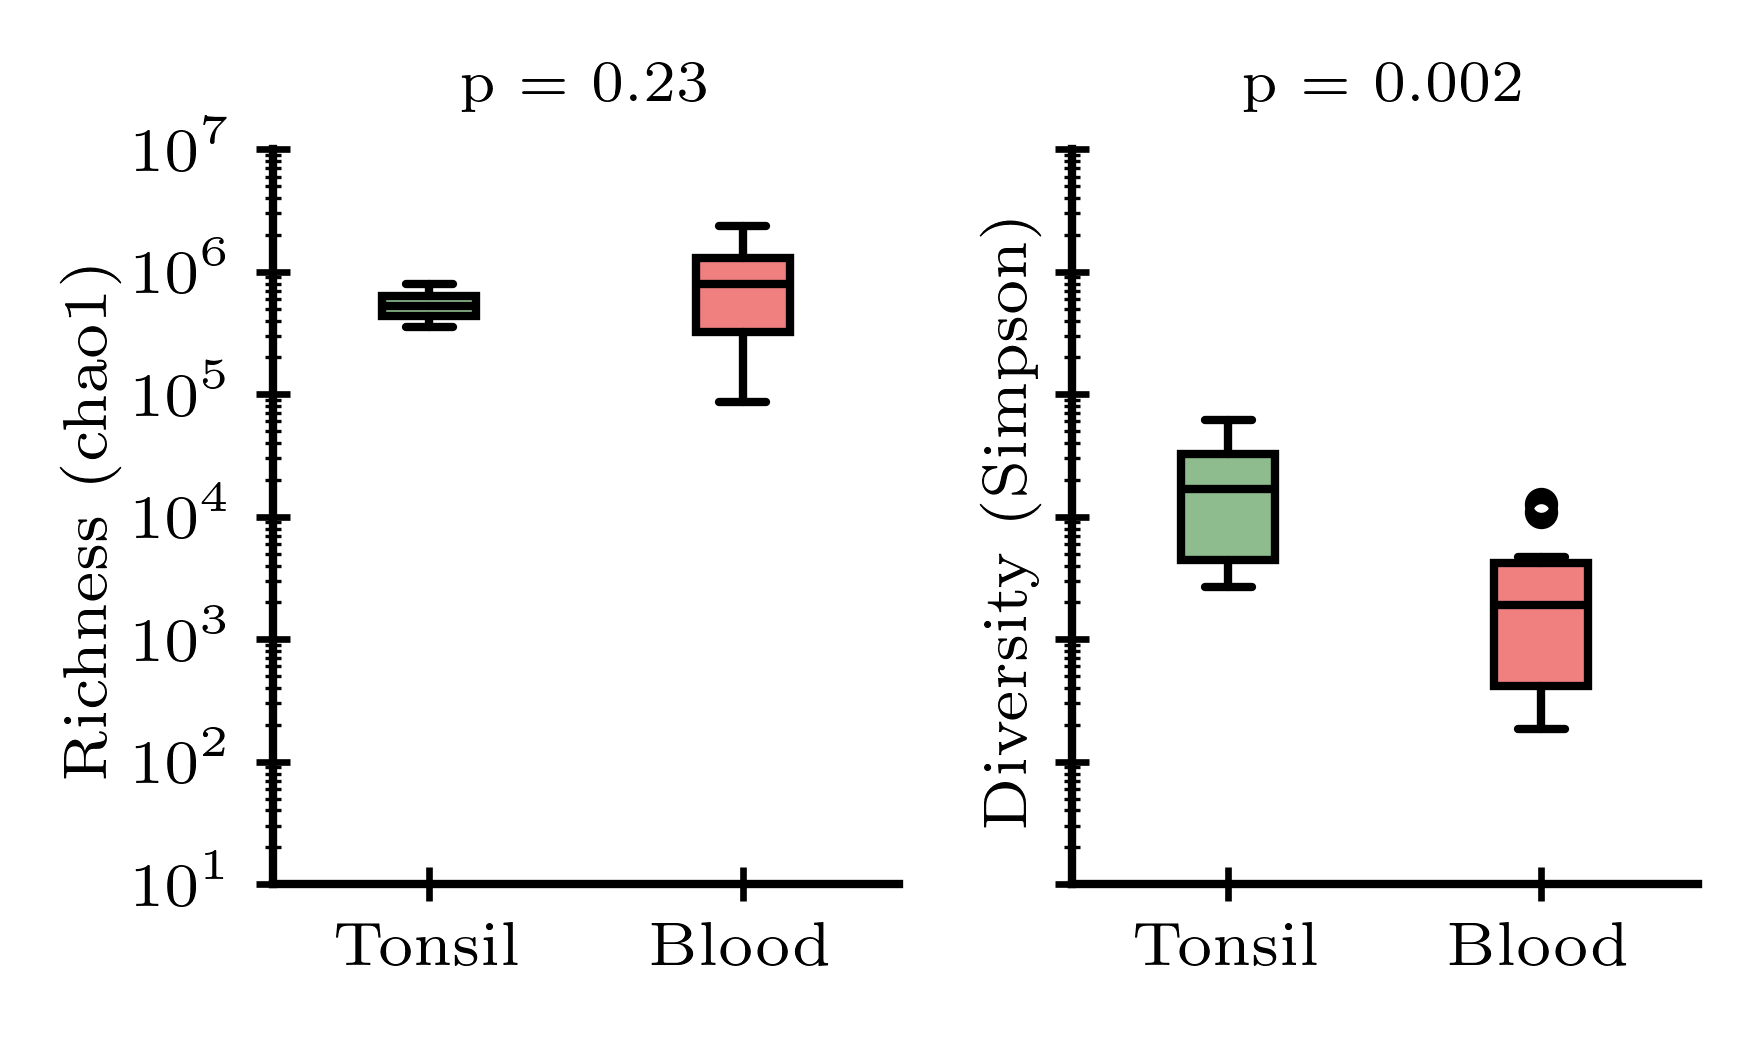

In [15]:
fig, ax = lib.plot_richness_and_diversity_differences(df_metrics[df_metrics['loc'] == 'tonsil'], df_metrics[df_metrics['loc'] == 'blood'], box_colors=["darkseagreen","lightcoral"],
                                                      x_labels=['Tonsil', 'Blood'], test='WCR')
plt.savefig('../../figures/how_to_maintain_diversity/tablo_diversity_blood_vs_tonsil.pdf', bbox_inches='tight', dpi=200, transparent=True);

### Tonsil vs global

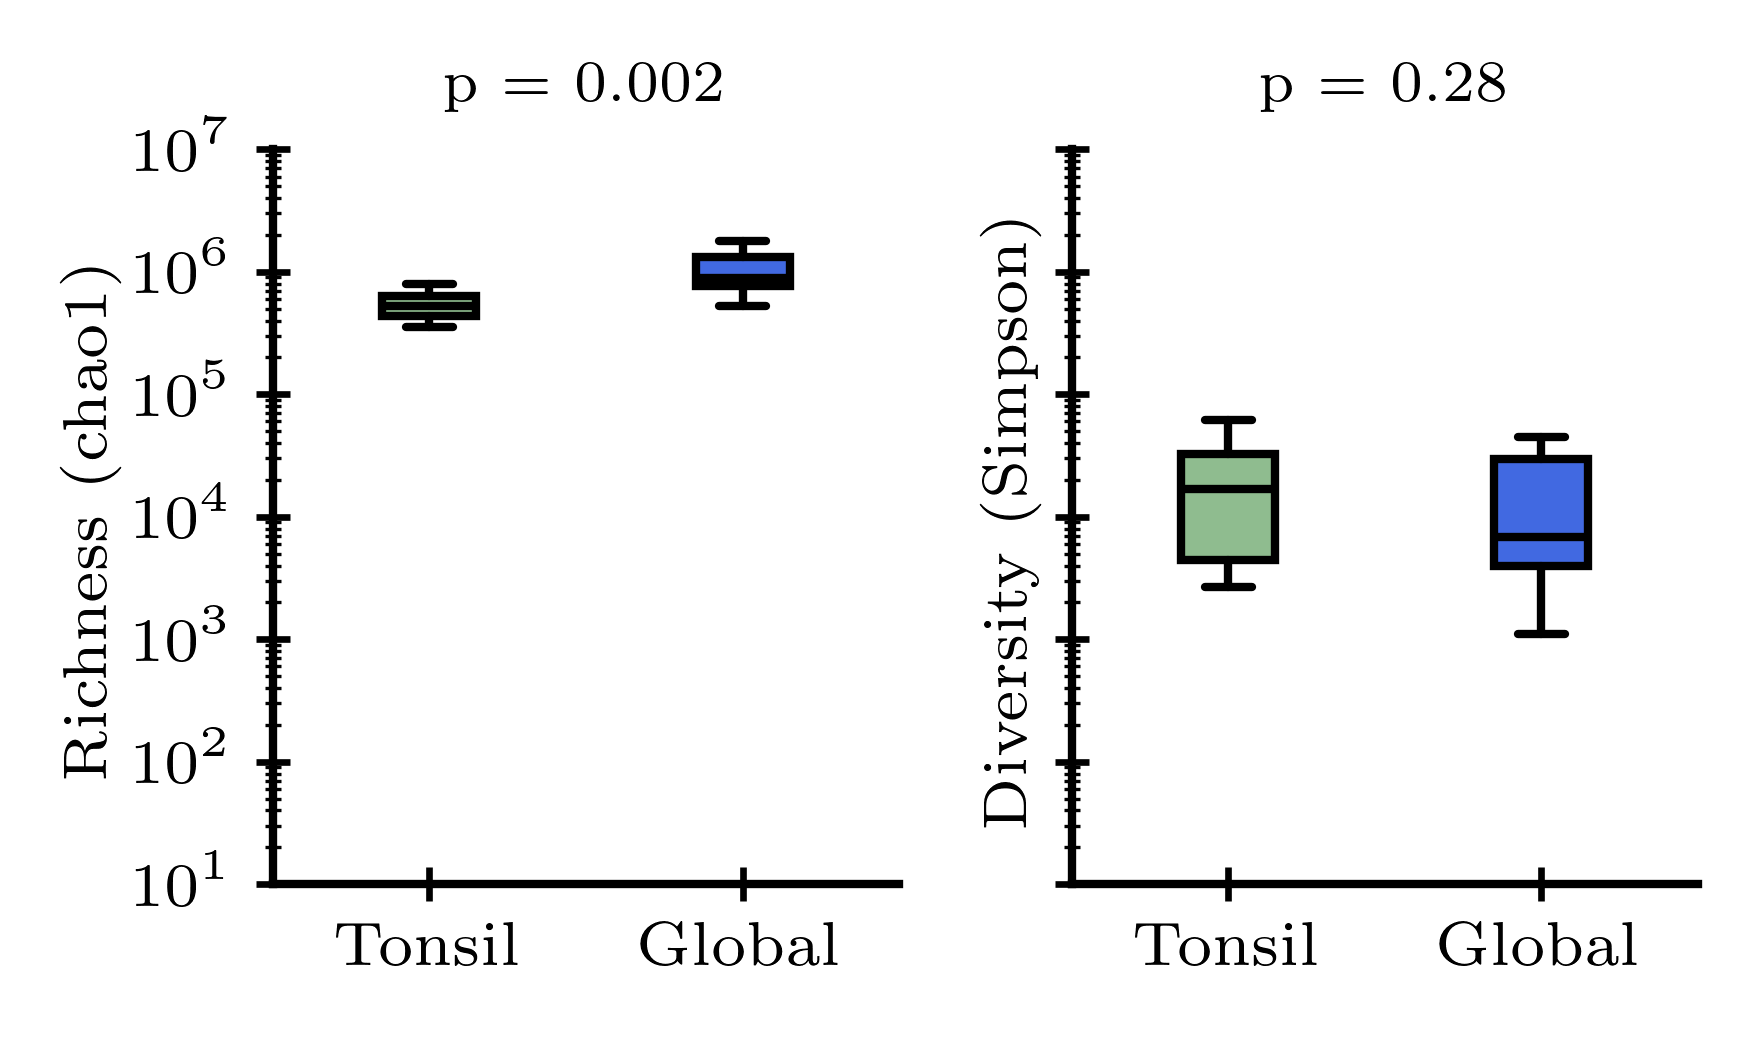

In [16]:
fig, ax = lib.plot_richness_and_diversity_differences(df_metrics[df_metrics['loc'] == 'tonsil'], df_metrics[df_metrics['loc'] == 'global'], box_colors=["darkseagreen","royalblue"],
                                                      x_labels=['Tonsil', 'Global'], test='WCR');

### Blood vs global

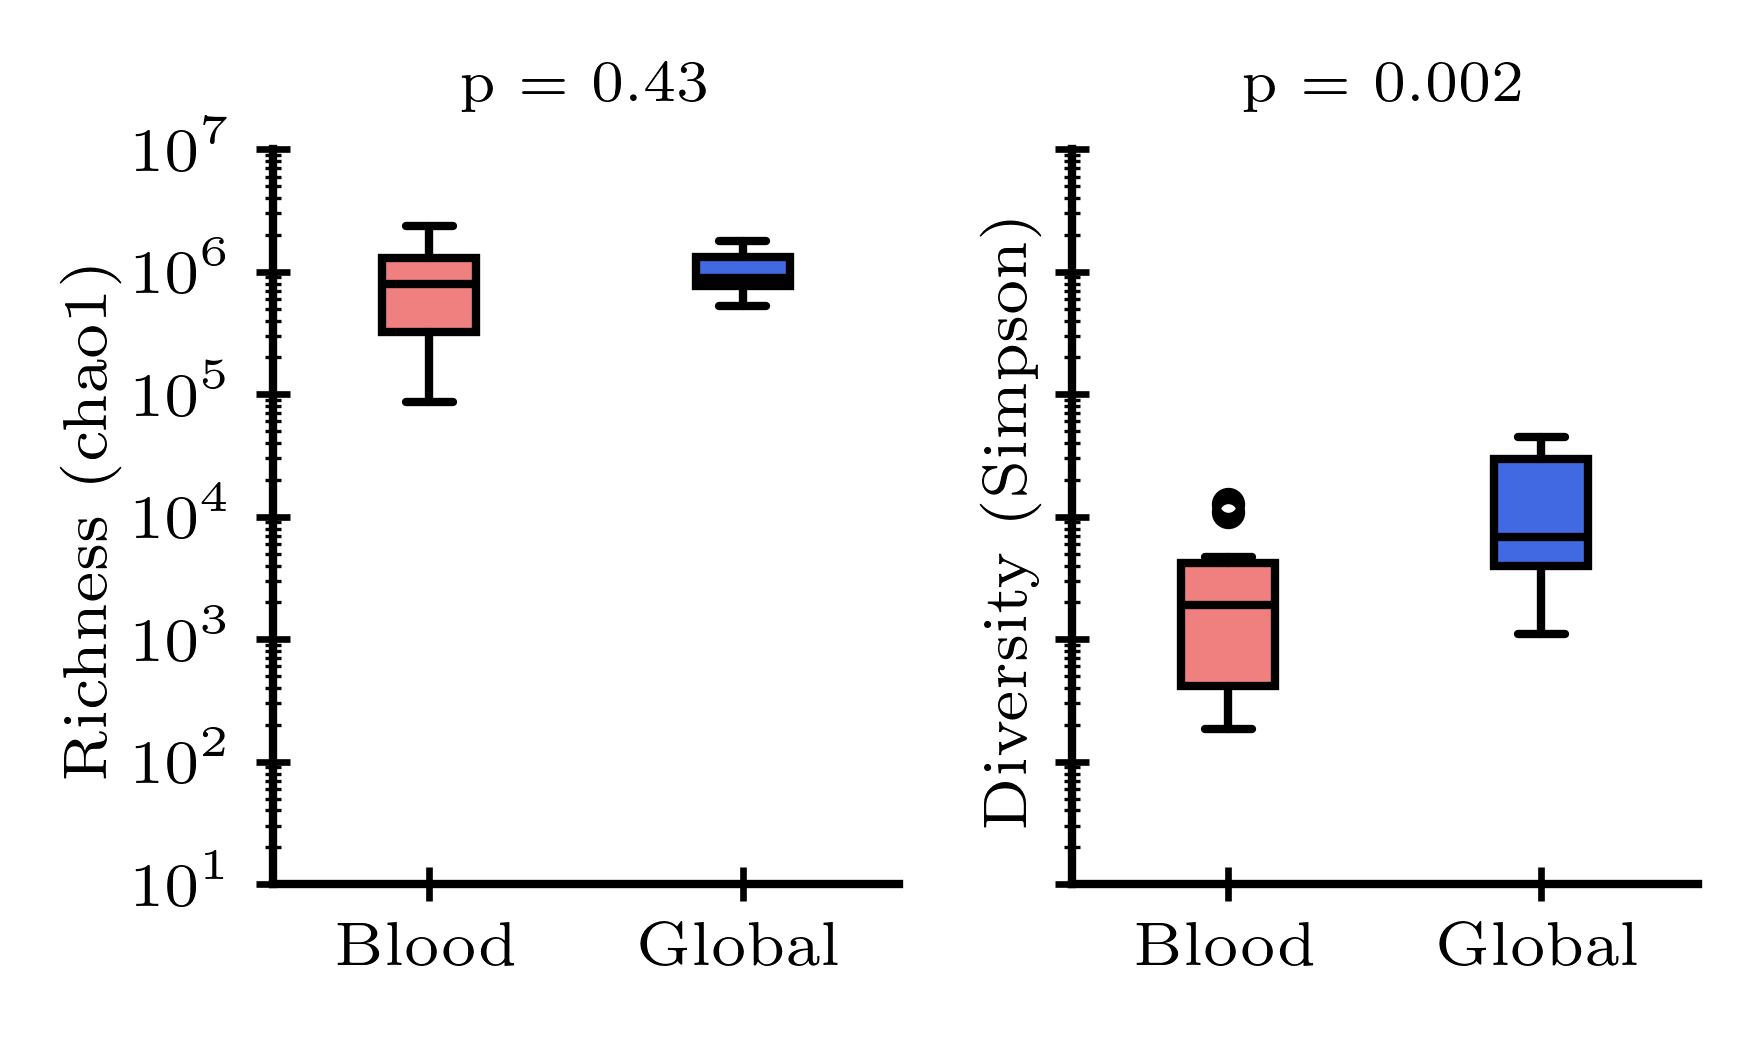

In [17]:
fig, ax = lib.plot_richness_and_diversity_differences(df_metrics[df_metrics['loc'] == 'blood'], df_metrics[df_metrics['loc'] == 'global'], box_colors=["lightcoral","royalblue"],
                                                      x_labels=['Blood', 'Global'], test='WCR');